# WHO COVID-19 Data — Weekly to Biweekly Conversion
**Input:** `WHO_COVID19_cleaned.csv` (output from the cleaning notebook)  
**Output:** `WHO_COVID19_cleaned_biweekly.csv`  
**Logic:** Group every 2 consecutive weeks per country and aggregate

---
## Step 0 — Imports & Configuration

In [4]:
import pandas as pd
import numpy as np
from IPython.display import display
%matplotlib inline
import matplotlib.pyplot as plt

INPUT_FILE = "../Data/WHO_COVID19_cleaned.csv"
OUTPUT_FILE = "../Data/WHO_COVID19_cleaned_biweekly.csv"    # output


---
## Step 1 — Load Cleaned Weekly Data

In [5]:
df = pd.read_csv(INPUT_FILE)
df['Date_reported'] = pd.to_datetime(df['Date_reported'])

print(f'Shape (weekly): {df.shape}')
print(f'Date range: {df["Date_reported"].min().date()} to {df["Date_reported"].max().date()}')
print(f'Countries: {df["Country"].nunique()}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Shape (weekly): (75840, 12)
Date range: 2020-01-05 to 2026-01-18
Countries: 240

Columns: ['Date_reported', 'Country_code', 'Country', 'WHO_region', 'New_cases', 'Cumulative_cases', 'New_deaths', 'Cumulative_deaths', 'Year', 'Week_num', 'flag_negative_correction', 'flag_extreme_spike']


,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,Year,Week_num,flag_negative_correction,flag_extreme_spike
0,2020-01-05,AF,Afghanistan,EMRO,0,0,0,0,2020,1,0,0
1,2020-01-12,AF,Afghanistan,EMRO,0,0,0,0,2020,2,0,0
2,2020-01-19,AF,Afghanistan,EMRO,0,0,0,0,2020,3,0,0
3,2020-01-26,AF,Afghanistan,EMRO,0,0,0,0,2020,4,0,0
4,2020-02-02,AF,Afghanistan,EMRO,0,0,0,0,2020,5,0,0


---
## Step 2 — Sort & Create Biweekly Groups

In [6]:
# Sort by country and date
df = df.sort_values(['Country', 'Date_reported']).reset_index(drop=True)

# Create biweekly group: every 2 consecutive weeks per country get the same group number
df['biweek_group'] = df.groupby('Country').cumcount() // 2

# Verify grouping for one country
sample_country = df['Country'].iloc[0]
print(f'Sample grouping for {sample_country}:')
display(
    df[df['Country'] == sample_country][['Date_reported', 'Country', 'New_cases', 'biweek_group']].head(10)
)
print('Each biweek_group number contains 2 consecutive weeks')

Sample grouping for Afghanistan:


,Date_reported,Country,New_cases,biweek_group
0,2020-01-05,Afghanistan,0,0
1,2020-01-12,Afghanistan,0,0
2,2020-01-19,Afghanistan,0,1
3,2020-01-26,Afghanistan,0,1
4,2020-02-02,Afghanistan,0,2
5,2020-02-09,Afghanistan,0,2
6,2020-02-16,Afghanistan,0,3
7,2020-02-23,Afghanistan,0,3
8,2020-03-01,Afghanistan,1,4
9,2020-03-08,Afghanistan,0,4


Each biweek_group number contains 2 consecutive weeks


---
## Step 3 — Aggregate to Biweekly

In [7]:
# Aggregation rules:
#   Date_reported       → last date in the 2-week window (end of biweek)
#   New_cases           → SUM (total cases over 2 weeks)
#   New_deaths          → SUM (total deaths over 2 weeks)
#   Cumulative_cases    → LAST (latest cumulative at end of biweek)
#   Cumulative_deaths   → LAST (latest cumulative at end of biweek)
#   Year                → LAST
#   Week_num            → LAST

df_biweekly = df.groupby(['Country', 'Country_code', 'WHO_region', 'biweek_group']).agg(
    Date_start=('Date_reported', 'first'),
    Date_reported=('Date_reported', 'last'),
    New_cases=('New_cases', 'sum'),
    New_deaths=('New_deaths', 'sum'),
    Cumulative_cases=('Cumulative_cases', 'last'),
    Cumulative_deaths=('Cumulative_deaths', 'last'),
    Year=('Year', 'last'),
    Week_num=('Week_num', 'last'),
    weeks_in_group=('Date_reported', 'count')
).reset_index()

print(f'Shape before: {df.shape[0]} rows (weekly)')
print(f'Shape after:  {df_biweekly.shape[0]} rows (biweekly)')
print(f'Expected reduction: ~50% → Actual: {(1 - df_biweekly.shape[0]/df.shape[0])*100:.1f}%')

Shape before: 75840 rows (weekly)
Shape after:  37920 rows (biweekly)
Expected reduction: ~50% → Actual: 50.0%


---
## Step 4 — Handle Edge Cases (Incomplete Biweeks)

In [8]:
# Some countries may have an odd number of weeks, so the last biweek has only 1 week
# Check how many biweeks have fewer than 2 weeks

incomplete = df_biweekly[df_biweekly['weeks_in_group'] < 2]
print(f'Biweeks with only 1 week: {len(incomplete)} (out of {len(df_biweekly)})')
print(f'These are typically the last biweek of each country with odd total weeks.')

if len(incomplete) > 0:
    print(f'\nSample incomplete biweeks:')
    display(incomplete[['Country', 'Date_start', 'Date_reported', 'New_cases', 'weeks_in_group']].head(10))

Biweeks with only 1 week: 0 (out of 37920)
These are typically the last biweek of each country with odd total weeks.


In [10]:
# Option A: Keep incomplete biweeks as-is (they represent 1 week of data)
# Option B: Drop them for cleaner analysis

# I'll go with Option A (keep them) but flag them
df_biweekly['flag_incomplete_biweek'] = (df_biweekly['weeks_in_group'] < 2).astype(int)

print(f"Flagged incomplete biweeks: {df_biweekly['flag_incomplete_biweek'].sum()}")


Flagged incomplete biweeks: 0


---
## Step 5 — Clean Up Columns

In [11]:
# Create a biweek label for readability
df_biweekly['Biweek_label'] = (
    df_biweekly['Date_start'].dt.strftime('%Y-%m-%d') + 
    ' to ' + 
    df_biweekly['Date_reported'].dt.strftime('%Y-%m-%d')
)

# Create a sequential biweek index per country
df_biweekly['Biweek_index'] = df_biweekly.groupby('Country').cumcount() + 1

# Drop helper columns
df_biweekly.drop(columns=['biweek_group', 'weeks_in_group'], inplace=True)

# Reorder columns
col_order = [
    'Date_start', 'Date_reported', 'Biweek_label', 'Biweek_index',
    'Country', 'Country_code', 'WHO_region',
    'New_cases', 'New_deaths',
    'Cumulative_cases', 'Cumulative_deaths',
    'Year', 'Week_num',
    'flag_incomplete_biweek'
]
df_biweekly = df_biweekly[col_order]

# Sort
df_biweekly = df_biweekly.sort_values(['Country', 'Date_reported']).reset_index(drop=True)

print('Columns in final biweekly dataset:')
for col in df_biweekly.columns:
    print(f'  {col:30s}  {str(df_biweekly[col].dtype)}')

Columns in final biweekly dataset:
  Date_start                      datetime64[us]
  Date_reported                   datetime64[us]
  Biweek_label                    str
  Biweek_index                    int64
  Country                         str
  Country_code                    str
  WHO_region                      str
  New_cases                       int64
  New_deaths                      int64
  Cumulative_cases                int64
  Cumulative_deaths               int64
  Year                            int64
  Week_num                        int64
  flag_incomplete_biweek          int64


---
## Step 6 — Validation

In [12]:
# 6a. Verify totals match: sum of biweekly New_cases should ≈ sum of weekly New_cases
weekly_total = df['New_cases'].sum()
biweekly_total = df_biweekly['New_cases'].sum()

print(f'Weekly total cases:   {weekly_total:,.0f}')
print(f'Biweekly total cases: {biweekly_total:,.0f}')
print(f'Match: {"Yes" if weekly_total == biweekly_total else "No — check aggregation"}')

Weekly total cases:   779,156,778
Biweekly total cases: 779,156,778
Match: Yes


In [13]:
# 6b. Verify for a single country
test_country = 'Australia'

weekly_aus = df[df['Country'] == test_country]['New_cases'].sum()
biweekly_aus = df_biweekly[df_biweekly['Country'] == test_country]['New_cases'].sum()

print(f'{test_country} weekly total:   {weekly_aus:,.0f}')
print(f'{test_country} biweekly total: {biweekly_aus:,.0f}')
print(f'Match: {"Yes" if weekly_aus == biweekly_aus else "No"}')

Australia weekly total:   11,861,161
Australia biweekly total: 11,861,161
Match: Yes


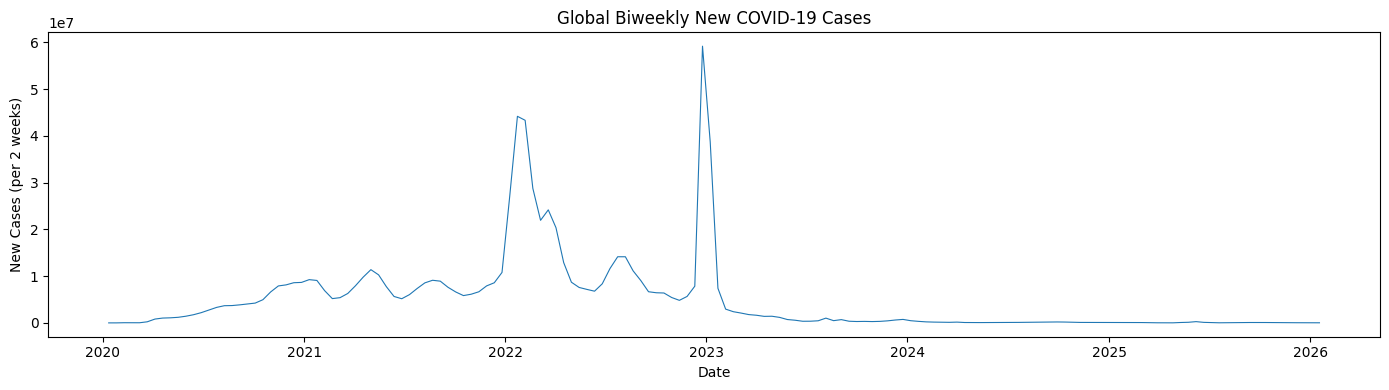

In [14]:
# 6c. Visual comparison — global biweekly cases
global_biweekly = df_biweekly.groupby('Date_reported')['New_cases'].sum()

plt.figure(figsize=(14, 4))
plt.plot(global_biweekly.index, global_biweekly.values, linewidth=0.8)
plt.title('Global Biweekly New COVID-19 Cases')
plt.xlabel('Date')
plt.ylabel('New Cases (per 2 weeks)')
plt.tight_layout()
plt.show()

In [15]:
# 6d. Summary
print('=' * 60)
print('BIWEEKLY DATA SUMMARY')
print('=' * 60)
print(f'Shape:               {df_biweekly.shape}')
print(f'Date range:          {df_biweekly["Date_reported"].min().date()} to {df_biweekly["Date_reported"].max().date()}')
print(f'Countries:           {df_biweekly["Country"].nunique()}')
print(f'Biweeks per country: ~{df_biweekly.groupby("Country")["Biweek_index"].max().median():.0f} (median)')
print(f'Missing values:      {df_biweekly.isnull().sum().sum()}')
print(f'Incomplete biweeks:  {df_biweekly["flag_incomplete_biweek"].sum()}')
print('=' * 60)

BIWEEKLY DATA SUMMARY
Shape:               (37920, 14)
Date range:          2020-01-12 to 2026-01-18
Countries:           240
Biweeks per country: ~158 (median)
Missing values:      0
Incomplete biweeks:  0


In [16]:
# 6e. Preview
print('Sample data (Australia):')
display(
    df_biweekly[df_biweekly['Country'] == 'Australia'].head(10)
)

Sample data (Australia):


,Date_start,Date_reported,Biweek_label,Biweek_index,Country,Country_code,WHO_region,New_cases,New_deaths,Cumulative_cases,Cumulative_deaths,Year,Week_num,flag_incomplete_biweek
1738,2020-01-05,2020-01-12,2020-01-05 to 2020-01-12,1,Australia,AU,WPRO,0,0,0,0,2020,2,0
1739,2020-01-19,2020-01-26,2020-01-19 to 2020-01-26,2,Australia,AU,WPRO,4,0,4,0,2020,4,0
1740,2020-02-02,2020-02-09,2020-02-02 to 2020-02-09,3,Australia,AU,WPRO,11,0,15,0,2020,6,0
1741,2020-02-16,2020-02-23,2020-02-16 to 2020-02-23,4,Australia,AU,WPRO,7,0,22,0,2020,8,0
1742,2020-03-01,2020-03-08,2020-03-01 to 2020-03-08,5,Australia,AU,WPRO,48,4,70,4,2020,10,0
1743,2020-03-15,2020-03-22,2020-03-15 to 2020-03-22,6,Australia,AU,WPRO,1011,5,1081,9,2020,12,0
1744,2020-03-29,2020-04-05,2020-03-29 to 2020-04-05,7,Australia,AU,WPRO,4554,27,5635,36,2020,14,0
1745,2020-04-12,2020-04-19,2020-04-12 to 2020-04-19,8,Australia,AU,WPRO,951,37,6586,73,2020,16,0
1746,2020-04-26,2020-05-03,2020-04-26 to 2020-05-03,9,Australia,AU,WPRO,197,26,6783,99,2020,18,0
1747,2020-05-10,2020-05-17,2020-05-10 to 2020-05-17,10,Australia,AU,WPRO,253,4,7036,103,2020,20,0


---
## Step 7 — Export

In [17]:
df_biweekly.to_csv(OUTPUT_FILE, index=False)
print(f'Saved biweekly data to: {OUTPUT_FILE}')
print(f'Shape: {df_biweekly.shape}')
print('Done ')

Saved biweekly data to: ../Data/WHO_COVID19_cleaned_biweekly.csv
Shape: (37920, 14)
Done 
